# Exploratory Data Analysis
Shenwei Zhang · **Course:** AIPI 510

**Source:** https://github.com/Welltory/hrv-covid19

# 1. Data Context, Provenance and Sampling

## 1.1 Data Context

The **Welltory COVID-19 and Wearables Open Data** release was published in 2020 by
Welltory, a consumer health-analytics app. Welltory asked users who believed they had
been exposed to or infected with SARS-CoV-2 to donate their app history to open research.
The release contains nine CSV tables covering 185 participants between 2019-12-31 and
2020-06-19.

**How the numbers were produced** — this determines how far each column can be trusted:

| Mechanism | How it works | Tables |
|---|---|---|
| In-app HRV measurement | Photoplethysmography (PPG): the user holds a fingertip on the phone camera, or wears a Bluetooth chest strap, for ~100–300 heartbeats | `hrv_measurements` |
| Connected-device sync | Pulled from Apple Health / Google Fit (Apple Watch, Garmin, etc.) | `wearables`, `sleep`, `heart_rate`, `blood_pressure` |
| Self-report | Profile fields and in-app questionnaires typed by the user | `participants`, `surveys` |

This matters twice over. The HRV table is **not clinical ECG** — a fingertip PPG reading
on a phone is vulnerable to finger movement and pressure changes, each of which inserts a
spurious beat interval (Section 8 shows this is the dominant source of extreme values).
And `participants` is a **self-reported profile**, never validated, which is why several
people are 250 cm tall and one reports COVID symptoms beginning in 1967.

## 1.2 Data Lineage and Provenance

- **Lineage:** Welltory app → GitHub repo `Welltory/hrv-covid19` → local copy in `data/week4/`.
  Files are read unmodified; no upstream cleaning was applied before loading.
- **Documentation:** column meanings and units come from the repository's own `datatypes.md`.
  Section 5 audits that documentation against the data and finds three disagreements.
- **De-identification:** users appear only as an opaque 10-character `user_code`; Welltory
  states no names or emails are included. `city` is retained, which is a mild
  re-identification surface, so geography is used only at country level here.
- **Licence:** Creative Commons, for scientific, commercial and free use.
- **Consent model:** opt-in donation by existing app users.

## 1.3 Data Sampling

This is a **convenience sample, not a probability sample**. To appear in it, a person had
to own a smartphone, already use a consumer HRV app, suspect COVID-19 infection, and
actively choose to donate their data. Consequences, quantified in Section 4:

- **Geography:** Russia (36%) and the United States (32%) supply two-thirds of participants
  — the app's commercial footprint, not the pandemic's.
- **Demographics:** 64% female; 58% aged 35–54; only 16 participants over 55. The age group
  COVID-19 hit hardest is the one this data describes worst.
- **Contribution:** the median participant contributed **4** measurements, the most active
  contributed **405**. The top 5 people account for 38% of all rows. Any statistic pooled
  across rows describes those five, not the cohort — which is why Section 10 computes
  between-person relationships on per-participant medians.

## 1.4 Scope

This notebook explores **two** of the nine tables — `hrv_measurements.csv` and
`participants.csv` — chosen on measured coverage

In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [15]:
sns.set_theme(style="whitegrid", context="notebook")
CAT = ["#0173B2", "#DE8F05", "#029E73", "#D55E00", "#CC78BC"]  # colour-blind-safe, fixed order
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

DATA = next(p for p in [Path("data/week4"), Path("../data/week4")] if p.exists())
hrv = pd.read_csv(DATA / "hrv_measurements.csv")
par = pd.read_csv(DATA / "participants.csv")

print(f"hrv_measurements : {hrv.shape[0]:,} rows x {hrv.shape[1]} cols, {hrv.user_code.nunique()} users")
print(f"participants     : {par.shape[0]:,} rows x {par.shape[1]} cols, {par.user_code.nunique()} users")

# Rationale for using these two of the nine tables: measured coverage of the 185 participants.
print("\nParticipant coverage per table (of 185):")
for p in sorted(DATA.glob("*.csv")):
    cols = pd.read_csv(p, nrows=1).columns
    if "user_code" in cols:
        n = pd.read_csv(p, usecols=["user_code"]).user_code.nunique()
        print(f"  {p.name:<24} {n:>3}  ({100 * n / 185:5.1f}%)")

hrv_measurements : 3,245 rows x 22 cols, 185 users
participants     : 185 rows x 8 cols, 185 users

Participant coverage per table (of 185):
  blood_pressure.csv        28  ( 15.1%)
  heart_rate.csv            79  ( 42.7%)
  hrv_measurements.csv     185  (100.0%)
  participants.csv         185  (100.0%)
  sleep.csv                 10  (  5.4%)
  surveys.csv              111  ( 60.0%)
  wearables.csv             79  ( 42.7%)
  weather.csv              104  ( 56.2%)


## 1.5 Rationale for the Table Choice

`hrv_measurements` and `participants` are the only two
tables that cover **100%** of participants; every other table is a funnel discarding 40–95%
of the cohort (`sleep` contains just 10 people). They also form a clean one-to-many pair,
and `hrv_measurements` uniquely includes `rr_data` — the raw beat-to-beat intervals behind
every summary metric — which lets Section 5 independently recompute the vendor's statistics
instead of trusting them. The trade-off: this pair contains no COVID symptom severity (that
lives in `surveys`), so disease enters only through `participants.symptoms_onset`.

---

# 2. What the Variables Represent

## Questions we are asking:
* What are the dimensions, data types and columns of each table?
* What do the variables actually represent, and in what units?
* Is the key relationship between the two tables sound?

Meanings and units below are from the repository's `datatypes.md`. Three of them do not
survive contact with the data — flagged here, settled empirically in Section 5.

### `participants` — one row per person, all self-reported

`user_code` (anonymised ID) · `gender` (m/f) · `age_range` (6 bands) · `city`, `country` ·
`height` (cm) · `weight` (kg) · `symptoms_onset` (date symptoms began, MM/DD/YYYY)

### `hrv_measurements` — one row per measurement session

**Context:** `rr_code` (measurement ID) · `measurement_datetime` · `time_of_day` ·
`how_feel`, `how_mood`, `how_sleep` (self-rating, −2 … +2) · `tags` (user labels;
documented as comma-separated — **it is not**) · `rr_data` (the raw series of intervals
between consecutive heartbeats, in ms)

**Time-domain HRV.** These describe how much the gap between heartbeats varies. A healthy
autonomic nervous system produces *more* variation; stress, illness and ageing compress it.

| Column | Meaning | Documented unit |
|---|---|---|
| `bpm` | Heart rate during the measurement | beats/min |
| `meanrr` | Mean RR — average time between beats | ms |
| `sdnn` | SD of the beat intervals; the standard overall-variability index | ms |
| `rmssd` | Root mean square of successive differences; fast, parasympathetic change | ms |
| `pnn50` | Share of intervals differing from the previous by >50 ms | % |
| `mxdmn` | Longest minus shortest interval | **seconds** |
| `mode` | Most common interval length | ms — **but the data says seconds** |
| `amo` | AMo50 — mode amplitude; how concentrated intervals are around the mode | % per 50 ms |

`mxdmn`, `mode` and `amo` are the three inputs to **Baevsky's stress index**, the
autonomic-regulation measure Welltory surfaces as its "stress" number. That formula expects
seconds, which is why two of them are stored that way. Section 9 rebuilds it as a feature.

**Frequency-domain HRV.** The interval series decomposed into oscillations by speed:
`lf` (0.04–0.15 Hz, mixed), `hf` (0.15–0.4 Hz, breathing-driven, parasympathetic),
`vlf` (<0.04 Hz), `lfhf` (LF/HF ratio), `total_power` (sum of the three), all in ms².

**A domain caveat that constrains everything.** HRV standards (Task Force, 1996) specify a
**5-minute** recording for frequency-domain analysis, and VLF is considered uninterpretable
on short records. Section 5 shows the median measurement here is **100 beats ≈ 84 seconds**.
SDNN, RMSSD and pNN50 are defensible at that length; LF, VLF and LF/HF are reported but
should not be over-read.

---

# 3. Data Structure


In [16]:
print("DIMENSIONS")
print(f"  participants     : {par.shape}")
print(f"  hrv_measurements : {hrv.shape}")

for name, d in [("participants", par), ("hrv_measurements", hrv)]:
    print(f"\nDATA TYPES & MISSINGNESS — {name}")
    print(pd.DataFrame({"dtype": d.dtypes.astype(str),
                        "missing": d.isna().sum(),
                        "missing_%": (100 * d.isna().mean()).round(1),
                        "n_unique": d.nunique()}).to_string())

print("\nKEY / REFERENTIAL INTEGRITY  (participants 1 --- N hrv_measurements)")
print("  participants.user_code is a unique primary key :", par.user_code.is_unique)
print("  hrv_measurements.rr_code is unique             :", hrv.rr_code.is_unique)
print("  HRV rows with no matching participant          :", len(set(hrv.user_code) - set(par.user_code)))
print("  Participants with no HRV record                :", len(set(par.user_code) - set(hrv.user_code)))

hrv["dt"] = pd.to_datetime(hrv.measurement_datetime)
print(f"  Collection window                              : {hrv.dt.min():%Y-%m-%d} to {hrv.dt.max():%Y-%m-%d}")

DIMENSIONS
  participants     : (185, 8)
  hrv_measurements : (3245, 22)

DATA TYPES & MISSINGNESS — participants
                  dtype  missing  missing_%  n_unique
user_code        object        0        0.0       185
gender           object        0        0.0         2
age_range        object        0        0.0         6
city             object       12        6.5       116
country          object        6        3.2        25
height          float64        2        1.1        54
weight          float64        0        0.0       142
symptoms_onset   object       38       20.5        74

DATA TYPES & MISSINGNESS — hrv_measurements
                        dtype  missing  missing_%  n_unique
user_code              object        0        0.0       185
rr_code                object        0        0.0      3245
measurement_datetime   object        0        0.0      3241
time_of_day            object        0        0.0         4
bpm                     int64        0        0.0      

## Interpretation

**Structure.** 185 participants described by 8 self-reported attributes, linked to 3,245
HRV sessions described by 22 columns. The relationship is a clean one-to-many: `user_code`
is a true primary key on the left, `rr_code` is unique on the right.

**Data integrity is complete in both directions** — zero orphan HRV rows and zero
participants without a measurement. This is unusual and valuable: it means no analysis in
this notebook is silently performed on a subset, unlike every other table pairing available
in this release.

**Three warning signs are already visible:**

1. `symptoms_onset` parses as `object`, not a date — free-text entry, resolved in Section 5.
2. Missingness ranges from 0% to 54.8%, and the worst three columns (`how_sleep`, `tags`,
   `symptoms_onset`) are missing for three *different* reasons. Section 6 treats them
   separately rather than applying one blanket rule.
3. `how_feel` and `how_mood` report **zero** missing values while `how_sleep` — a question
   on the same screen — is missing 54.8% of the time. Three sibling questions cannot
   plausibly have completion rates of 100%, 100% and 45%. That asymmetry is the signature
   of a **disguised missing value**, confirmed in Section 6.

---

# 4. Descriptive Statistics

## Questions we are asking:
* What are the central tendency and dispersion of each numeric variable?
* Are the distributions normal or skewed, and do they need transformation?
* Do the values make sense given the physiological domain?

In [17]:
HRV_NUM = ["bpm", "meanrr", "sdnn", "rmssd", "pnn50", "mxdmn", "mode",
           "amo", "lf", "hf", "vlf", "lfhf", "total_power"]

print("DESCRIPTIVE STATISTICS — hrv_measurements")
desc = hrv[HRV_NUM].describe().T[["mean", "50%", "std", "min", "max"]]
desc.columns = ["mean", "median", "std", "min", "max"]
desc["skew"] = hrv[HRV_NUM].skew()
print(desc.round(2).to_string())

print("\nDESCRIPTIVE STATISTICS — participants")
print(par[["height", "weight"]].describe().T[["mean", "50%", "std", "min", "max"]].round(2).to_string())

print("\nCATEGORICAL DISTRIBUTIONS")
print("  gender      :", par.gender.value_counts().to_dict())
print("  age_range   :", par.age_range.value_counts().sort_index().to_dict())
print("  top country :", par.country.value_counts().head(3).to_dict())
print("  time_of_day :", hrv.time_of_day.value_counts().to_dict())

mpu = hrv.groupby("user_code").size()
print(f"\nSAMPLING — measurements per participant: median={mpu.median():.0f}, max={mpu.max()}, "
      f"single-measurement users={int((mpu == 1).sum())}/{len(mpu)}, "
      f"top-5 users={100 * mpu.nlargest(5).sum() / len(hrv):.1f}% of all rows")

DESCRIPTIVE STATISTICS — hrv_measurements
                mean   median      std     min       max  skew
bpm            73.26    72.00    12.20   44.00    125.00  0.48
meanrr        839.60   829.10   137.42  477.73   1346.74  0.33
sdnn           52.49    46.92    29.37    9.52    206.63  1.72
rmssd          52.81    42.87    39.35    6.34    310.80  2.66
pnn50          20.62    16.16    18.59    0.00     91.92  1.41
mxdmn           0.18     0.16     0.11    0.03      0.79  1.69
mode            0.84     0.82     0.14    0.48      1.32  0.39
amo            46.79    45.00    16.42   12.00     98.00  0.53
lf            927.04   423.00  1455.42    2.00  15522.00  3.80
hf           1125.04   380.00  2490.54    4.00  33490.00  5.34
vlf           578.23   293.00   876.68    1.00  18468.00  6.05
lfhf            2.40     0.86     5.75    0.03    105.62  7.98
total_power  2630.31  1387.00  3912.25   44.00  41118.00  3.79

DESCRIPTIVE STATISTICS — participants
          mean     50%    std     min

## Interpretation

**Central tendency is physiologically sensible.** Median heart rate 72 bpm, median mean-RR
829 ms, median SDNN 47 ms and RMSSD 43 ms all sit squarely in the normal adult range for
short resting recordings. The data is not obviously corrupted at the centre.

**Dispersion and skew are not.** The five power metrics are extremely right-skewed —
`lfhf` at **7.98**, `vlf` at 6.05, `hf` at 5.34 — with maxima 40–80× their own medians
(`total_power` median 1,387 vs max 41,118). Time-domain metrics are milder but still
skewed (`rmssd` 2.66). Two implications follow: means are misleading for these columns so
**medians and Spearman correlations are used throughout**, and a variance-stabilising
transformation is needed before any modelling (Section 9).

**`mode` cannot be in the documented units.** Its median is 0.82 while `meanrr` in the same
row is 829, and the two measure almost the same quantity. They differ by a factor of ~1,000
— tested directly in Section 5.

**`participants` contains impossible values.** Height ranges to **250 cm** and weight to
154 kg. No adult is 250 cm tall; this is a self-report typo, not a tall person.

**The panel is severely unbalanced.** Median 4 measurements per person, max 405, 54 people
(29%) appear exactly once, and the top 5 supply 38% of all rows. Pooling rows would produce
a weighted average with weights nobody chose, and would treat repeated readings from one
person as independent observations. **Decision: every between-person relationship in
Section 10 is computed on per-participant medians (n = 185), never on pooled rows.**

---

# 5. Data Quality Assessment

## Questions we are asking:
* Is the data complete, and where is it not?
* Is it **accurate** — can the reported metrics be independently verified?
* Is it **consistent** with its own published documentation?
* Does it have **integrity** — do derived columns obey their own definitions?
* Are records unique?

In [18]:
# A six-dimension programmatic data-quality audit.
rr = hrv.rr_data.apply(lambda s: np.fromstring(s, sep=","))   # raw beat-to-beat intervals
hrv["n_beats"] = rr.apply(len)

print("== 1. COMPLETENESS ==")
comp = pd.concat([(100 * par.isna().mean()).rename("participants"),
                  (100 * hrv.drop(columns=["dt", "n_beats"]).isna().mean()).rename("hrv")], axis=1).round(1)
print(comp[comp.sum(axis=1) > 0].to_string())
print(f"  Overall cell completeness: participants {100 - 100 * par.isna().to_numpy().mean():.1f}%, "
      f"hrv {100 - 100 * hrv.isna().to_numpy().mean():.1f}%")

print("\n== 2. ACCURACY: recompute the vendor's metrics from the raw rr_data signal ==")
chk = pd.DataFrame({
    "meanrr": rr.apply(np.mean),
    "sdnn":   rr.apply(lambda a: np.std(a, ddof=1)),
    "rmssd":  rr.apply(lambda a: np.sqrt(np.mean(np.diff(a) ** 2))),
    "pnn50":  rr.apply(lambda a: 100 * np.mean(np.abs(np.diff(a)) > 50)),
})
for c in chk.columns:
    print(f"  {c:<7} reported vs recomputed: pearson r={hrv[c].corr(chk[c]):.4f}  "
          f"mean|diff|={np.abs(hrv[c] - chk[c]).mean():.4f}")
print(f"  RR intervals outside a physiologically possible 300-2000 ms: "
      f"{int(rr.apply(lambda a: ((a < 300) | (a > 2000)).any()).sum())} measurements")

onset = pd.to_datetime(par.symptoms_onset, format="%m/%d/%Y", errors="coerce")
bad_onset = onset.notna() & ~onset.between("2019-11-01", "2020-07-31")
bad_h = par.height.notna() & ~par.height.between(130, 220)
print(f"  participants.height outside 130-220 cm : {int(bad_h.sum())} -> {sorted(par.loc[bad_h, 'height'])}")
print(f"  symptoms_onset outside the study window: {int(bad_onset.sum())} -> "
      f"{sorted(onset[bad_onset].dt.strftime('%Y-%m-%d'))}")

print("\n== 3. CONSISTENCY: does the data match the published data dictionary? ==")
print(f"  datatypes.md says `mode` is in ms; meanrr/mode ratio = {(hrv.meanrr / hrv['mode']).median():.1f}"
      f"  -> `mode` is actually in SECONDS")
print(f"  datatypes.md says `tags` is comma-separated; rows containing ','="
      f"{int(hrv.tags.fillna('').str.contains(',').sum())}, rows containing ';'="
      f"{int(hrv.tags.fillna('').str.contains(';').sum())}  -> the separator is ';'")
print(f"  datatypes.md defines pnn50 as deviation from the MEAN, but the values match the standard")
print(f"    SUCCESSIVE-difference definition exactly (r={hrv.pnn50.corr(chk.pnn50):.4f}) -> the docs are wrong")
print(f"  height decimals reveal conversion from inches (170.18 = 67 in x 2.54): "
      f"{int((par.height.round(2) % 1 != 0).sum())}/{par.height.notna().sum()} non-integer heights")

print("\n== 4. INTEGRITY: do the derived columns obey their own definitions? ==")
print(f"  total_power == lf+hf+vlf    : median abs error "
      f"{np.abs(hrv.total_power - (hrv.lf + hrv.hf + hrv.vlf)).median():.3f}")
print(f"  lfhf        == lf/hf        : median abs error {np.abs(hrv.lfhf - hrv.lf / hrv.hf).median():.5f}")
print(f"  bpm         == 60000/meanrr : mean abs error {np.abs(hrv.bpm - 60000 / hrv.meanrr).mean():.3f} (rounding)")

print("\n== 5. UNIQUENESS ==")
print(f"  exact duplicate rows            : hrv={hrv.duplicated().sum()}, participants={par.duplicated().sum()}")
print(f"  duplicate rr_code (primary key) : {hrv.duplicated('rr_code').sum()}")
print(f"  duplicate (user_code, datetime) : {hrv.duplicated(['user_code', 'measurement_datetime']).sum()}")
print(f"  duplicate raw rr_data signals   : {hrv.duplicated('rr_data').sum()}")

print("\n== 6. VALIDITY: is each measurement long enough for the metrics reported on it? ==")
print(f"  beats per measurement: median={hrv.n_beats.median():.0f}, min={hrv.n_beats.min()}, max={hrv.n_beats.max()}")
print(f"  duration in seconds  : median={(rr.apply(np.sum) / 1000).median():.0f}s "
      f"(HRV standards require 300s for LF/VLF)")

== 1. COMPLETENESS ==
                participants   hrv
city                     6.5   NaN
country                  3.2   NaN
height                   1.1   NaN
symptoms_onset          20.5   NaN
how_sleep                NaN  54.8
tags                     NaN  32.2
  Overall cell completeness: participants 96.1%, hrv 96.4%

== 2. ACCURACY: recompute the vendor's metrics from the raw rr_data signal ==
  meanrr  reported vs recomputed: pearson r=1.0000  mean|diff|=0.0000
  sdnn    reported vs recomputed: pearson r=1.0000  mean|diff|=0.0003
  rmssd   reported vs recomputed: pearson r=1.0000  mean|diff|=0.0002
  pnn50   reported vs recomputed: pearson r=1.0000  mean|diff|=0.0019
  RR intervals outside a physiologically possible 300-2000 ms: 0 measurements
  participants.height outside 130-220 cm : 2 -> [248.92, 250.0]
  symptoms_onset outside the study window: 13 -> ['1967-01-30', '1968-08-15', '1975-03-28', '1977-11-20', '1981-11-26', '1982-12-16', '1984-04-05', '1987-07-07', '1993-01-01

## Interpretation

**Data profiling and completeness.** Overall cell completeness is high — 96.1% for
`participants` and 96.4% for `hrv_measurements` — but it is not evenly spread. Six columns
carry all of the missingness, and the profile above shows it concentrated in exactly the
places where a user had to type something optional: `how_sleep` (54.8%), `tags` (32.2%),
`symptoms_onset` (20.5%), `city` (6.5%), `country` (3.2%), `height` (1.1%). Every measured
physiological column is 100% complete, because the app computes it rather than asking for it.
Completeness here is therefore a proxy for *user effort*, not for sensor reliability.

**Data accuracy.** This dataset allows an unusually strong accuracy test: `rr_data` stores
the raw beat-to-beat intervals the summary metrics were computed from, so the vendor's
numbers can be recomputed from scratch. All four time-domain metrics reproduce with
**r = 1.0000** and a mean absolute difference below 0.002 ms. Every one of the 3,245
measurements also consists entirely of physiologically possible intervals (300–2000 ms,
i.e. 30–200 bpm), with zero violations. **The computed columns are accurate.**

The *self-reported* columns are not. Two participants report heights of 248.9 cm and
250 cm, and **13 participants give a symptom-onset date outside the study window** —
including 1967-01-30, 1975-03-28 and 1993-01-01, which are birth years rather than onset
dates, and 2022-04-21, which is in the future relative to collection. This is the sharpest
finding of the audit: **accuracy in this dataset is a property of the collection mechanism,
not of the dataset as a whole.** Anything the algorithm produced is trustworthy; anything a
human typed needs validation.

**Data consistency.** Three concrete disagreements between the release and its own
`datatypes.md`:

1. `mode` is documented in milliseconds but the `meanrr`/`mode` ratio is **1000.8** — it is
   stored in **seconds**. Two columns in the same table, measuring the same physical
   quantity, in different units.
2. `tags` is documented as comma-separated. **Zero** rows contain a comma; **1,538** contain
   a semicolon. Code written to the documentation would silently fail to parse.
3. `pnn50` is documented as deviation from the *mean*, but the values match the standard
   *successive-difference* definition exactly (r = 1.0000). The implementation is correct
   and the documentation is wrong.

A fourth internal inconsistency: 53 of 183 heights carry non-integer decimals that decode
as inch conversions (170.18 = 67 in × 2.54), so metric and imperial entry paths are mixed
in a single column.

**Data integrity.** Beyond the referential integrity established in Section 3, three columns
are algebraically derived from others and all three hold exactly: `total_power = lf+hf+vlf`
(median error 0.000), `lfhf = lf/hf` (0.00025), and `bpm = 60000/meanrr` (0.411, consistent
with rounding to a whole bpm). The internal logic is sound — but it also means these
columns carry **no independent information**, which Section 10 confirms with correlations of
|ρ| ≈ 1.0 and which is why they are treated as redundant rather than as features.

**Uniqueness.** All four duplicate tests return zero: no exact duplicate rows, no repeated
primary key, no repeated (user, timestamp) pair, and no two identical raw signals. Section 7
shows this is *not* the end of the duplicate question.

**Validity.** The median measurement is **100 beats ≈ 84 seconds**. This is adequate for
SDNN, RMSSD and pNN50, but international HRV standards require 5 minutes for
frequency-domain analysis — so `lf`, `vlf` and `lfhf` are structurally under-powered here.
They are retained for completeness and deliberately down-weighted in interpretation.

---

# 6. Missing Values


In [19]:
# Strategy: flag-and-keep rather than drop. Deleting rows would destroy the panel
# structure and would silently discard exactly the least engaged users.
par_c, hrv_c = par.copy(), hrv.copy()

# (a) symptoms_onset — MNAR. Missing almost certainly means "never had symptoms",
#     which is information. 13 further dates fall outside the study window (birth
#     years, a future date) and are treated as missing rather than trusted.
par_c["onset"] = pd.to_datetime(par_c.symptoms_onset, format="%m/%d/%Y", errors="coerce")
n_impossible = int((par_c.onset.notna() & ~par_c.onset.between("2019-11-01", "2020-07-31")).sum())
par_c.loc[~par_c.onset.between("2019-11-01", "2020-07-31"), "onset"] = pd.NaT
par_c["onset_reported"] = par_c.onset.notna()

# (b) height — 2 blank + 2 impossible (248.9, 250 cm) -> NaN, NOT imputed.
#     Imputing would fabricate a body measurement for a named individual.
n_bad_h = int((par_c.height.notna() & ~par_c.height.between(130, 220)).sum())
par_c.loc[par_c.height.notna() & ~par_c.height.between(130, 220), "height"] = np.nan

# (c) country — explicit "Unknown" category instead of row deletion.
par_c["country"] = par_c.country.fillna("Unknown")

# (d) how_sleep — MAR. Keep NaN, add an explicit response flag.
hrv_c["sleep_reported"] = hrv_c.how_sleep.notna()

# (e) how_feel / how_mood — DISGUISED missing: 0 means both "neutral" and "skipped".
#     Detect users who never move off 0 across five or more measurements.
act = hrv_c.groupby("user_code").filter(lambda g: len(g) >= 5)
always0 = act.groupby("user_code")[["how_feel", "how_mood"]].apply(lambda g: (g == 0).all())
flat = set(always0[always0.any(axis=1)].index)
hrv_c["selfreport_suspect"] = hrv_c.user_code.isin(flat)

# (f) tags — structurally missing: blank means "the user added no tags", not "unknown".
hrv_c["n_tags"] = hrv_c.tags.fillna("").apply(lambda s: 0 if not s.strip() else len(s.split(";")))

print("MISSING-VALUE TREATMENT")
print(f"  symptoms_onset : {par.symptoms_onset.isna().sum()} blank + {n_impossible} impossible dates "
      f"-> {int((~par_c.onset_reported).sum())}/185 flagged 'no onset reported' (MNAR, not imputed)")
print(f"  height         : {par.height.isna().sum()} blank + {n_bad_h} impossible "
      f"-> {int(par_c.height.isna().sum())} NaN (not imputed)")
print(f"  country        : {par.country.isna().sum()} -> filled with an 'Unknown' category")
print(f"  how_sleep      : {hrv.how_sleep.isna().sum()} ({100 * hrv.how_sleep.isna().mean():.1f}%) "
      f"kept NaN + sleep_reported flag")
print(f"  how_feel/mood  : 0% 'missing', but {100 * (hrv.how_feel == 0).mean():.1f}% are exactly 0; "
      f"{len(flat)} of {act.user_code.nunique()} active users NEVER move off 0 -> selfreport_suspect flag")
print(f"  tags           : {hrv.tags.isna().sum()} ({100 * hrv.tags.isna().mean():.1f}%) "
      f"-> n_tags = 0 (structurally missing)")
print(f"\n  Rows dropped for missingness: 0  (flag-and-keep preserves the panel structure)")

MISSING-VALUE TREATMENT
  symptoms_onset : 38 blank + 13 impossible dates -> 51/185 flagged 'no onset reported' (MNAR, not imputed)
  height         : 2 blank + 2 impossible -> 4 NaN (not imputed)
  country        : 6 -> filled with an 'Unknown' category
  how_sleep      : 1779 (54.8%) kept NaN + sleep_reported flag
  how_feel/mood  : 0% 'missing', but 60.9% are exactly 0; 15 of 85 active users NEVER move off 0 -> selfreport_suspect flag
  tags           : 1044 (32.2%) -> n_tags = 0 (structurally missing)

  Rows dropped for missingness: 0  (flag-and-keep preserves the panel structure)


## Interpretation and Rationale

The six affected columns are missing for **four different reasons**, so a single blanket
rule (drop rows, or impute the median) would be wrong for at least three of them.

| Column | Mechanism | Treatment | Rationale |
|---|---|---|---|
| `symptoms_onset` | **MNAR** | Flag, never impute | Missingness is the signal: a blank almost certainly means "I never had symptoms". Imputing a date would invent an illness. |
| `height` | MCAR (2) + invalid (2) | Set to NaN | 250 cm is a typo, not a tall person. Imputing would fabricate a body measurement for a specific individual; BMI is simply undefined for those 4. |
| `country` | MCAR | "Unknown" category | Only 3.2%, and dropping those rows would bias geography toward the majority countries. |
| `how_sleep` | MAR | Keep NaN + flag | A subjective rating cannot be imputed — there is no ground truth to impute toward. |
| `how_feel`, `how_mood` | **Disguised** | Flag suspect users | The most dangerous case, because it looks complete. |
| `tags` | **Structurally missing** | `n_tags = 0` | Blank means "added no tags", which is a real value, not an unknown. |

**The disguised-missing case deserves its own note.** `how_feel` and `how_mood` report zero
missing values, yet 60.9% of all answers are exactly `0` and **15 of the 85 participants
with five or more measurements never once move off 0**. A person who genuinely feels neutral
every single time across dozens of sessions is implausible; far more likely, `0` is the
default position of the slider and those users simply never touched it. The column is
therefore *complete but not informative* for those users, and `selfreport_suspect` marks
them so the distinction survives into Section 10.

**Why nothing was dropped.** Deleting incomplete rows would remove the participants who
engaged least with the optional fields — precisely the people whose data is hardest to
replace — and would shrink a panel that is already dominated by five heavy users. Flagging
keeps every row auditable and lets each analysis decide its own exclusions.

---

# 7. Duplicate Records

## Questions we are asking:
* Are there duplicated records, at any definition of "duplicate"?
* Does the answer change when we define duplication at the analysis grain rather than the row?

In [20]:
print("DUPLICATE INVESTIGATION — five levels, from strictest to loosest")
print(f"  L1 exact duplicate rows              : {hrv_c.duplicated().sum()}")
print(f"  L2 duplicate primary key (rr_code)   : {hrv_c.duplicated('rr_code').sum()}")
print(f"  L3 duplicate business key (user+time): {hrv_c.duplicated(['user_code', 'measurement_datetime']).sum()}")
print(f"  L4 duplicate raw signal (rr_data)    : {hrv_c.duplicated('rr_data').sum()}")

# L5 — near-duplicates: the same person measuring again a few minutes later.
h = hrv_c.sort_values(["user_code", "dt"]).copy()
h["gap_min"] = h.groupby("user_code")["dt"].diff().dt.total_seconds() / 60
for t in [1, 5, 15, 60]:
    print(f"  L5 within {t:>2} min of the same user's previous reading: {int((h.gap_min < t).sum())}")

h["is_retest"] = h.gap_min < 15
hrv_c = h.sort_index()
hrv_dedup = hrv_c[~hrv_c.is_retest]

print(f"\n  Retest sessions flagged (<15 min apart): {int(hrv_c.is_retest.sum())} "
      f"({100 * hrv_c.is_retest.mean():.1f}% of rows)")
print(f"  Analysis grain after keeping the first reading of each burst: "
      f"{len(hrv_dedup):,} rows (was {len(hrv_c):,})")

# Join fan-out check: a 1:N merge must not inflate the row count.
_m = hrv_dedup.merge(par_c, on="user_code", how="left", validate="many_to_one")
print(f"  Join fan-out check: {len(hrv_dedup):,} rows in -> {len(_m):,} rows out (no inflation)")

DUPLICATE INVESTIGATION — five levels, from strictest to loosest
  L1 exact duplicate rows              : 0
  L2 duplicate primary key (rr_code)   : 0
  L3 duplicate business key (user+time): 0
  L4 duplicate raw signal (rr_data)    : 0
  L5 within  1 min of the same user's previous reading: 1
  L5 within  5 min of the same user's previous reading: 154
  L5 within 15 min of the same user's previous reading: 249
  L5 within 60 min of the same user's previous reading: 364

  Retest sessions flagged (<15 min apart): 249 (7.7% of rows)
  Analysis grain after keeping the first reading of each burst: 2,996 rows (was 3,245)
  Join fan-out check: 2,996 rows in -> 2,996 rows out (no inflation)


## Interpretation and Rationale

**At every strict definition, this dataset is clean.** No exact duplicate rows, no repeated
`rr_code`, no repeated (user, timestamp) pair, and — the strongest test — no two identical
raw `rr_data` signals anywhere in 3,245 measurements. A duplicated export or a double-insert
would have shown up at level 4, because two independent 100-beat recordings being
byte-identical is essentially impossible. `df.drop_duplicates()` would change nothing here.

**But "no duplicate rows" is not the same as "no duplicated information."** 249 measurements
(7.7%) were taken within 15 minutes of the same person's previous one — 154 of them within
5 minutes. These are not copies; they are *retests*, where a user disliked a reading and
immediately took another. They are near-duplicates at the level that matters: they describe
the same physiological moment, and treating them as independent observations would
double-count that moment and understate the variance between sessions.

**Rationale for the 15-minute threshold.** HRV genuinely shifts over tens of minutes with
posture, activity and digestion, so a gap of an hour is a new state; a gap of two minutes is
the same state measured twice. The counts cluster accordingly — 154 within 5 minutes, only
115 more between 5 and 15 minutes, and a flatter 115 between 15 and 60 — so 15 minutes sits
where retesting behaviour ends and normal repeat measurement begins. **Treatment: keep the
first reading of each burst and flag the rest, rather than averaging them.** The first
reading is the unprompted one; later readings in a burst are conditioned on the user having
judged the first unsatisfactory, which is a selection effect we do not want to average in.

**Integrity check on the merge.** Joining 2,996 deduplicated measurements to 185
participants returns exactly 2,996 rows, with `validate="many_to_one"` asserting the
cardinality. No fan-out, which confirms `user_code` is a genuine key on the participant side.

---

# 8. Outliers

## Questions we are asking:
* Are there extreme values, and does a standard statistical rule identify them correctly?
* Are the extremes real physiology, or measurement noise?

In [21]:
# artefact_rate: share of beats differing more than 20% from the previous beat.
# A missed or double-counted pulse in PPG produces exactly this signature.
hrv_c["artifact_rate"] = rr.apply(lambda a: 100 * np.mean(np.abs(np.diff(a)) / a[:-1] > 0.20))
hrv_dedup = hrv_c[~hrv_c.is_retest]

q1, q3 = hrv_c.rmssd.quantile([.25, .75]); iqr = q3 - q1
iqr_out = hrv_c.rmssd > q3 + 1.5 * iqr
r_art = stats.spearmanr(hrv_c.artifact_rate, hrv_c.rmssd)

print("OUTLIER INVESTIGATION")
print(f"  Tukey IQR rule flags {int(iqr_out.sum())} high-RMSSD rows ({100 * iqr_out.mean():.1f}%), "
      f"max RMSSD = {hrv_c.rmssd.max():.1f} ms")
print(f"  But every RR interval is physiologically possible (0 outside 300-2000 ms),")
print(f"  so we test whether the extremes are BIOLOGY or MEASUREMENT NOISE:\n")
print(f"    artifact_rate: median={hrv_c.artifact_rate.median():.1f}%, max={hrv_c.artifact_rate.max():.1f}%, "
      f"share of measurements above 5%: {100 * (hrv_c.artifact_rate > 5).mean():.1f}%")
print(f"    Spearman(artifact_rate, rmssd) = {r_art.statistic:+.3f}  (p = {r_art.pvalue:.1e})")
print(f"    Of the {int(iqr_out.sum())} IQR-flagged rows, "
      f"{100 * (hrv_c.loc[iqr_out, 'artifact_rate'] > 5).mean():.1f}% have >5% artefacts, "
      f"vs {100 * (hrv_c.loc[~iqr_out, 'artifact_rate'] > 5).mean():.1f}% of the rest")

hrv_c["low_quality"] = hrv_c.artifact_rate > 5
print(f"\n  DECISION: flag {int(hrv_c.low_quality.sum())} low-quality measurements "
      f"({100 * hrv_c.low_quality.mean():.1f}%) and exclude them from Section 8,")
print(f"  rather than clipping or winsorising by percentile.")

OUTLIER INVESTIGATION
  Tukey IQR rule flags 195 high-RMSSD rows (6.0%), max RMSSD = 310.8 ms
  But every RR interval is physiologically possible (0 outside 300-2000 ms),
  so we test whether the extremes are BIOLOGY or MEASUREMENT NOISE:

    artifact_rate: median=0.0%, max=63.6%, share of measurements above 5%: 11.7%
    Spearman(artifact_rate, rmssd) = +0.780  (p = 0.0e+00)
    Of the 195 IQR-flagged rows, 99.0% have >5% artefacts, vs 6.2% of the rest

  DECISION: flag 381 low-quality measurements (11.7%) and exclude them from Section 8,
  rather than clipping or winsorising by percentile.


## Interpretation and Rationale

A Tukey IQR rule flags 195 high-RMSSD measurements (6.0%), topping out at 310.8 ms — roughly
seven times the median. The usual next step is to winsorise or clip them. **That would be
the wrong call here, and the raw signal proves why.**

Every one of those 3,245 measurements consists entirely of physiologically possible beat
intervals (300–2000 ms). Nothing is out of range at the level of an individual heartbeat.
So the extreme RMSSD values are not impossible readings — they are readings whose
beat-to-beat *jumps* are extreme, which is the exact signature of a PPG artefact: a missed
pulse makes one interval look double-length, and a double-counted pulse halves it.

Testing that directly: `artifact_rate` — the share of beats differing more than 20% from the
previous beat — correlates with RMSSD at **ρ = +0.78**. And the decisive number: **99.0% of
the IQR-flagged rows have an artefact rate above 5%, versus 6.2% of everything else.** The
statistical outliers and the noisy recordings are very nearly the same set of rows.

**Rationale for flagging by signal quality rather than clipping by percentile.**

1. **Clipping treats the symptom, not the cause.** Winsorising RMSSD to the 99th percentile
   would leave the same bad recordings in the dataset with plausible-looking values, which
   is worse than an obvious outlier — it hides the problem.
2. **A percentile rule has no defensible cut-point.** Why the 99th and not the 95th? The
   artefact rule has a physiological justification: a 20% beat-to-beat jump exceeds what
   sinus rhythm produces at rest, so it indicates either arrhythmia or a detection error,
   and either way the summary metrics are not measuring what they claim to.
3. **It is not one-sided.** An IQR rule on RMSSD only catches high values, but the same bad
   recordings also corrupt SDNN, pNN50 and every power metric. One quality flag handles all
   of them at once.
4. **Flagging is reversible; deleting is not.** All 3,245 rows are kept. `low_quality` marks
   the 381 (11.7%) affected, and each analysis decides whether to exclude them.

There is a real cost to acknowledge: because artefacts inflate variability, excluding noisy
readings systematically removes high-HRV measurements, which biases the retained sample
slightly downward. That is the correct trade — a biased-low estimate of real physiology
beats an unbiased estimate of noise — but it is a trade, not a free lunch.

---

# 9. Transformation and Feature Engineering

## Questions we are asking:
* Do any variables need transformation before analysis?
* What new features can be derived, and what do they add?

In [22]:
AGE_ORDER = ["18-24", "25-34", "35-44", "45-54", "55-64", "65-74"]
df = hrv_c[~hrv_c.is_retest].merge(par_c, on="user_code", how="left", validate="many_to_one")

# --- Transformation 1: log1p for the heavily right-skewed power metrics.
SKEWED = ["lf", "hf", "vlf", "total_power", "lfhf"]
before = df[SKEWED].skew()
for c in SKEWED:
    df["log_" + c] = np.log1p(df[c])
after = df[["log_" + c for c in SKEWED]].skew()

# --- Transformation 2: ordinal encoding of the age bands (they are ordered, not nominal).
df["age_ord"] = df.age_range.map({a: i for i, a in enumerate(AGE_ORDER)})

# --- Transformation 3: put `mode` and `mxdmn` into ms, so the table has one time unit.
df["mode_ms"], df["mxdmn_ms"] = df["mode"] * 1000, df["mxdmn"] * 1000

# --- FEATURE 1: BMI — body composition, unavailable from either column alone.
df["bmi"] = df.weight / (df.height / 100) ** 2
df["bmi_class"] = pd.cut(df.bmi, [0, 18.5, 25, 30, 100], labels=["under", "normal", "over", "obese"])

# --- FEATURE 2: artifact_rate (built in Cell 15) — a signal-quality feature recovered
#     from the raw waveform, describing how much to trust each row.

# --- FEATURE 3: illness timeline, from the cleaned onset date joined to measurement date.
df["days_since_onset"] = (df.dt.dt.normalize() - df.onset).dt.days
df["illness_phase"] = pd.cut(df.days_since_onset, [-10**6, -1, 7, 28, 10**6],
                             labels=["pre-onset", "acute (0-7d)", "sub-acute (8-28d)", "recovery (>28d)"])
df["illness_phase"] = df.illness_phase.cat.add_categories("no onset reported").fillna("no onset reported")

# --- FEATURE 4: Baevsky stress index = AMo / (2 * Mode * MxDMn).
#     The formula expects Mode and MxDMn in seconds, which is how they are stored (Cell 9).
df["stress_index"] = df.amo / (2 * df["mode"] * df.mxdmn)

print("TRANSFORMATIONS")
print(pd.DataFrame({"skew_raw": before.values, "skew_log1p": after.values}, index=SKEWED).round(2).to_string())
print("  age_range -> age_ord (ordinal 0-5);  mode/mxdmn converted to ms for unit consistency")

print("\nNEW FEATURES")
print(f"  bmi           : median={df.groupby('user_code').bmi.first().median():.1f}, "
      f"classes={df.groupby('user_code').bmi_class.first().value_counts().to_dict()}")
print(f"  artifact_rate : median={df.artifact_rate.median():.1f}%  (signal-quality feature from rr_data)")
print(f"  illness_phase : {df.groupby('illness_phase', observed=True).size().to_dict()}")
print(f"  stress_index  : median={df.stress_index.median():.0f}")
print(f"\nAnalysis dataset: {df.shape[0]:,} rows x {df.shape[1]} cols, {df.user_code.nunique()} participants")

TRANSFORMATIONS
             skew_raw  skew_log1p
lf               3.84       -0.21
hf               5.30        0.29
vlf              6.38       -0.31
total_power      3.83        0.02
lfhf             8.05        1.74
  age_range -> age_ord (ordinal 0-5);  mode/mxdmn converted to ms for unit consistency

NEW FEATURES
  bmi           : median=26.3, classes={'normal': 65, 'over': 58, 'obese': 47, 'under': 11}
  artifact_rate : median=0.0%  (signal-quality feature from rr_data)
  illness_phase : {'pre-onset': 613, 'acute (0-7d)': 143, 'sub-acute (8-28d)': 736, 'recovery (>28d)': 976, 'no onset reported': 528}
  stress_index  : median=169

Analysis dataset: 2,996 rows x 53 cols, 185 participants


## Interpretation and Rationale

### Transformations

**`log1p` on the five power metrics.** Skewness falls from 3.8–8.1 to roughly −0.3 … +0.3
for four of the five — near-symmetric. `lfhf` improves from 8.05 to 1.74 but stays skewed,
because it is a ratio of two already-skewed quantities. `log1p` rather than `log` because
these are power values bounded below at zero, and `log1p` is defined there. **Rationale:**
the untransformed columns make means meaningless and would let a handful of measurements
dominate any distance-based or linear method.

**Ordinal encoding of `age_range`.** The six bands are ordered, so one-hot encoding would
discard that ordering and treat 18–24 as no more distant from 65–74 than from 25–34.

**Unit harmonisation.** `mode` and `mxdmn` are converted to ms so the table carries one time
unit. Both originals are kept, because the Baevsky formula below needs the seconds version.

### New features

**1. `bmi` and `bmi_class`** — neither `height` nor `weight` alone describes body
composition; their ratio does. It is the single strongest predictor of HRV found in
Section 10 (ρ = −0.42 against total power), and it turns a pair of raw self-reports into a
variable with a clinical interpretation. Undefined for the 4 participants whose height was
removed in Section 6 — deliberately, rather than imputed.

**2. `artifact_rate`** — the feature this dataset uniquely makes possible. Rather than
describing the person, it describes **how much to trust the row**, recovered by re-deriving
beat-to-beat volatility from the raw `rr_data` waveform. It is what turned the outlier
question from a statistical guess into an empirical answer, and it is the input to
`low_quality`.

**3. `days_since_onset` and `illness_phase`** — the only cross-table feature here, joining
each measurement's timestamp to that participant's cleaned symptom-onset date to place the
reading on an illness timeline. The four clinical windows (pre-onset, acute 0–7 d, sub-acute
8–28 d, recovery >28 d) follow the typical COVID-19 course. "No onset reported" is kept as
an explicit fifth level rather than dropped, so the MNAR group from Section 6 stays visible
instead of silently vanishing.

**4. `stress_index`** — Baevsky's stress index, `AMo / (2 × Mode × MxDMn)`. This is the
payoff from the unit inconsistency found in Section 5: `mode` and `mxdmn` are stored in seconds
*because* this formula requires seconds, so what looked like a documentation bug turned out
to be a deliberate design choice. It compresses three columns into the composite Welltory
itself surfaces as "stress". **Caveat:** the index is defined for 5-minute recordings and
these are ~84 seconds, so the absolute level (median 169, versus a textbook normal band of
50–150) is inflated; it is used for comparison between groups, not as a clinical value.

---

# 10. Relationships Among Variables

## Questions we are asking:
* Which variables are related to each other, and how strongly?
* Which relationships survive a correct treatment of the unbalanced panel?

A. WITHIN-TABLE: Spearman correlation among the 13 HRV metrics
   Strongest pairs (|rho| > 0.9) — algebraically redundant columns:
     bpm          ~ meanrr       rho = -1.00
     meanrr       ~ mode         rho = +0.99
     mode         ~ bpm          rho = -0.99
     sdnn         ~ mxdmn        rho = +0.92

B. BETWEEN-PERSON: one row per participant (median of their readings)
   Rationale: 5 people supply 38% of the rows, so pooled rows would describe them, not the cohort.
   n = 174 participants
          relationship   n  spearman_rho  p_value sig
        age_ord ~ sdnn 174        -0.254 7.22e-04 ***
       age_ord ~ rmssd 174        -0.142 6.25e-02  ns
         age_ord ~ bpm 174        -0.109 1.53e-01  ns
 age_ord ~ total_power 174        -0.357 1.33e-06 ***
age_ord ~ stress_index 174         0.243 1.24e-03  **
            bmi ~ sdnn 171        -0.362 1.12e-06 ***
           bmi ~ rmssd 171        -0.226 3.00e-03  **
             bmi ~ bpm 171         0.201 8.34e-03  **
     bmi 

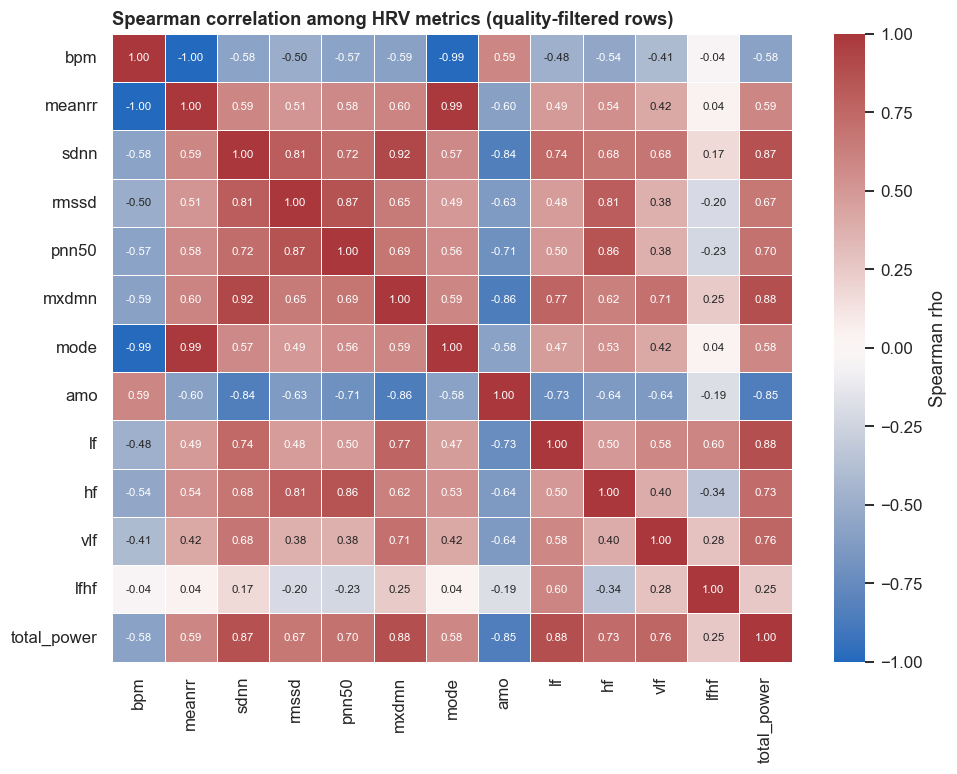

In [23]:
good = df[~df.low_quality]

print("A. WITHIN-TABLE: Spearman correlation among the 13 HRV metrics")
corr = good[HRV_NUM].corr(method="spearman")
red = corr.where(~np.eye(len(corr), dtype=bool)).abs().unstack().dropna().sort_values(ascending=False)
print("   Strongest pairs (|rho| > 0.9) — algebraically redundant columns:")
for (a, b), v in red[red > 0.9].iloc[::2].items():
    print(f"     {a:<12} ~ {b:<12} rho = {corr.loc[a, b]:+.2f}")

print("\nB. BETWEEN-PERSON: one row per participant (median of their readings)")
print("   Rationale: 5 people supply 38% of the rows, so pooled rows would describe them, not the cohort.")
u = (good.groupby("user_code")
     .agg(n=("bpm", "size"), sdnn=("sdnn", "median"), rmssd=("rmssd", "median"), bpm=("bpm", "median"),
          total_power=("total_power", "median"), stress_index=("stress_index", "median"),
          age_ord=("age_ord", "first"), age_range=("age_range", "first"),
          gender=("gender", "first"), bmi=("bmi", "first")).reset_index())
print(f"   n = {len(u)} participants")


def sig(p):
    return "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"


rows = []
for x in ["age_ord", "bmi"]:
    for y in ["sdnn", "rmssd", "bpm", "total_power", "stress_index"]:
        d = u[[x, y]].dropna(); r = stats.spearmanr(d[x], d[y])
        rows.append({"relationship": f"{x} ~ {y}", "n": len(d),
                     "spearman_rho": round(r.statistic, 3), "p_value": f"{r.pvalue:.2e}", "sig": sig(r.pvalue)})
d = u[["age_ord", "bmi"]].dropna(); r = stats.spearmanr(d.age_ord, d.bmi)
rows.append({"relationship": "age_ord ~ bmi", "n": len(d), "spearman_rho": round(r.statistic, 3),
             "p_value": f"{r.pvalue:.2e}", "sig": sig(r.pvalue)})
print(pd.DataFrame(rows).to_string(index=False))

print("\nC. GROUP DIFFERENCES (Mann-Whitney U, per-participant medians)")
for y in ["bpm", "sdnn", "rmssd"]:
    a, b = u[u.gender == "f"][y].dropna(), u[u.gender == "m"][y].dropna()
    p = stats.mannwhitneyu(a, b).pvalue
    print(f"   {y:<6} female {a.median():6.1f} vs male {b.median():6.1f}   p={p:.4f} {sig(p)}")

print("\nD. WITHIN-PERSON: circadian effect (row level is correct here — repetition IS the signal)")
print(f"   median RMSSD by time_of_day: {good.groupby('time_of_day').rmssd.median().round(1).to_dict()}")
print(f"   Kruskal-Wallis p = {stats.kruskal(*[g.rmssd.values for _, g in good.groupby('time_of_day')]).pvalue:.2e}")

print("\nE. ILLNESS TIMELINE (the engineered feature)")
phase = good.groupby("illness_phase", observed=True).agg(
    n=("bpm", "size"), bpm=("bpm", "median"), sdnn=("sdnn", "median"),
    rmssd=("rmssd", "median"), stress_index=("stress_index", "median"))
print(phase.round(1).to_string())
kw = stats.kruskal(*[g.sdnn.values for _, g in good.groupby("illness_phase", observed=True)])
print(f"   Kruskal-Wallis sdnn ~ illness_phase: p = {kw.pvalue:.3f}")

print("\nF. STATISTICAL vs PRACTICAL SIGNIFICANCE")
r_row = stats.spearmanr(good.how_feel, good.sdnn)
pu = good.groupby("user_code")[["how_feel", "sdnn"]].median().dropna()
r_usr = stats.spearmanr(pu.how_feel, pu.sdnn)
print(f"   how_feel ~ sdnn, ROW level (n={len(good):,})     : rho={r_row.statistic:+.3f}, p={r_row.pvalue:.1e}")
print(f"   how_feel ~ sdnn, PARTICIPANT level (n={len(pu)}) : rho={r_usr.statistic:+.3f}, p={r_usr.pvalue:.3f}")

fig, ax = plt.subplots(figsize=(9, 7.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1,
            linewidths=.5, annot_kws={"size": 7.5}, cbar_kws={"label": "Spearman rho"}, ax=ax)
ax.set_title("Spearman correlation among HRV metrics (quality-filtered rows)",
             loc="left", fontweight="semibold")
plt.tight_layout(); plt.show()

## Interpretation

**Within the HRV table, four pairs are effectively the same variable.** `bpm ~ meanrr` at
**ρ = −1.00** is a perfect inverse, as it must be — one is 60000 divided by the other.
`meanrr ~ mode` (+0.99) and `mode ~ bpm` (−0.99) follow, since the modal interval tracks the
mean interval almost exactly at rest. `sdnn ~ mxdmn` (+0.92) is near-redundant for the same
reason: both measure spread. Practically, the 13 "metrics" contain closer to 5 or 6
independent dimensions, and any model using all of them would be severely collinear.

**Between people, body composition beats age.** On per-participant medians (n = 174):

- **BMI ~ total power: ρ = −0.416 (p = 1.6e-08)** — the strongest relationship in the
  dataset. Higher BMI, markedly lower HRV.
- **BMI ~ stress index: ρ = +0.400**, BMI ~ SDNN: −0.362, BMI ~ RMSSD: −0.226, BMI ~ bpm:
  +0.201 — every HRV metric moves in the direction of reduced autonomic flexibility.
- **Age ~ total power: ρ = −0.357 (p = 1.3e-06)**, age ~ SDNN: −0.254, age ~ stress index:
  +0.243. The decline of HRV with age is the single most replicated finding in the HRV
  literature, and it reproduces cleanly here.
- Age and BMI are themselves correlated (ρ = +0.284), so these two effects are partly
  entangled and neither should be read as causal in isolation.

Notably, RMSSD and bpm show weaker age associations than total power does. That is
consistent with the domain: RMSSD is the metric most contaminated by artefacts (Section 8), so
it carries the most residual noise even after filtering.

**Gender differences are real but modest.** Women have a higher median heart rate (77.0 vs
70.8 bpm, p = 0.007) and lower SDNN (42.1 vs 47.4, p = 0.033); RMSSD does not differ
significantly (p = 0.25). Both significant findings match established physiology.

**The circadian effect is the strongest signal in the entire dataset** (Kruskal-Wallis
p = 2e-18): median RMSSD is 42.8 ms in the morning versus 34.1 ms in the evening — a 25%
swing. This is the one place where row-level analysis is correct rather than a mistake,
because the question is about within-person variation and repeated measurement is exactly
what answers it. It also carries a practical warning: **time of day is a larger source of
variation than illness status**, so comparing users who measure in the morning with users
who measure at night would confound circadian rhythm with whatever else is being studied.

**The illness timeline produces a mostly negative result, reported honestly.** Across the
four clinical phases, median SDNN is 42.2 / 40.6 / 42.3 / 42.1 — essentially flat. The
Kruskal-Wallis test does return p = 0.001, but the group driving it is **"no onset
reported"** (SDNN 46.1, stress index 159 vs ~210 for everyone else), not any illness phase.
That is a **selection effect, not a disease effect**: people who never reported symptoms are
healthier, which is unsurprising and says nothing about COVID-19 progression. With only 123
measurements in the acute window, the analysis is also underpowered. The honest conclusion
is that this data, at this sample size and with this much circadian noise, does not detect
an acute HRV signature.

**A methodological finding worth more than the others.** `how_feel ~ sdnn` at row level
gives ρ = +0.060 with **p = 0.002** — "significant" by any conventional threshold. On
per-participant medians the same relationship is ρ = −0.032, p = 0.67 — and the sign flips.
The row-level p-value is an artefact of pseudo-replication: with 2,634 rows drawn from 174
people, n is inflated roughly fifteenfold and almost anything clears p < 0.05. This is
precisely why Section B uses per-participant medians, and it is a concrete demonstration
that **statistical significance and practical significance are different things.**

---

# 11. Visual Exploration

## Questions we are asking:
* Do the visualisations confirm the numeric findings?
* Do they reveal anything the summary statistics hide?

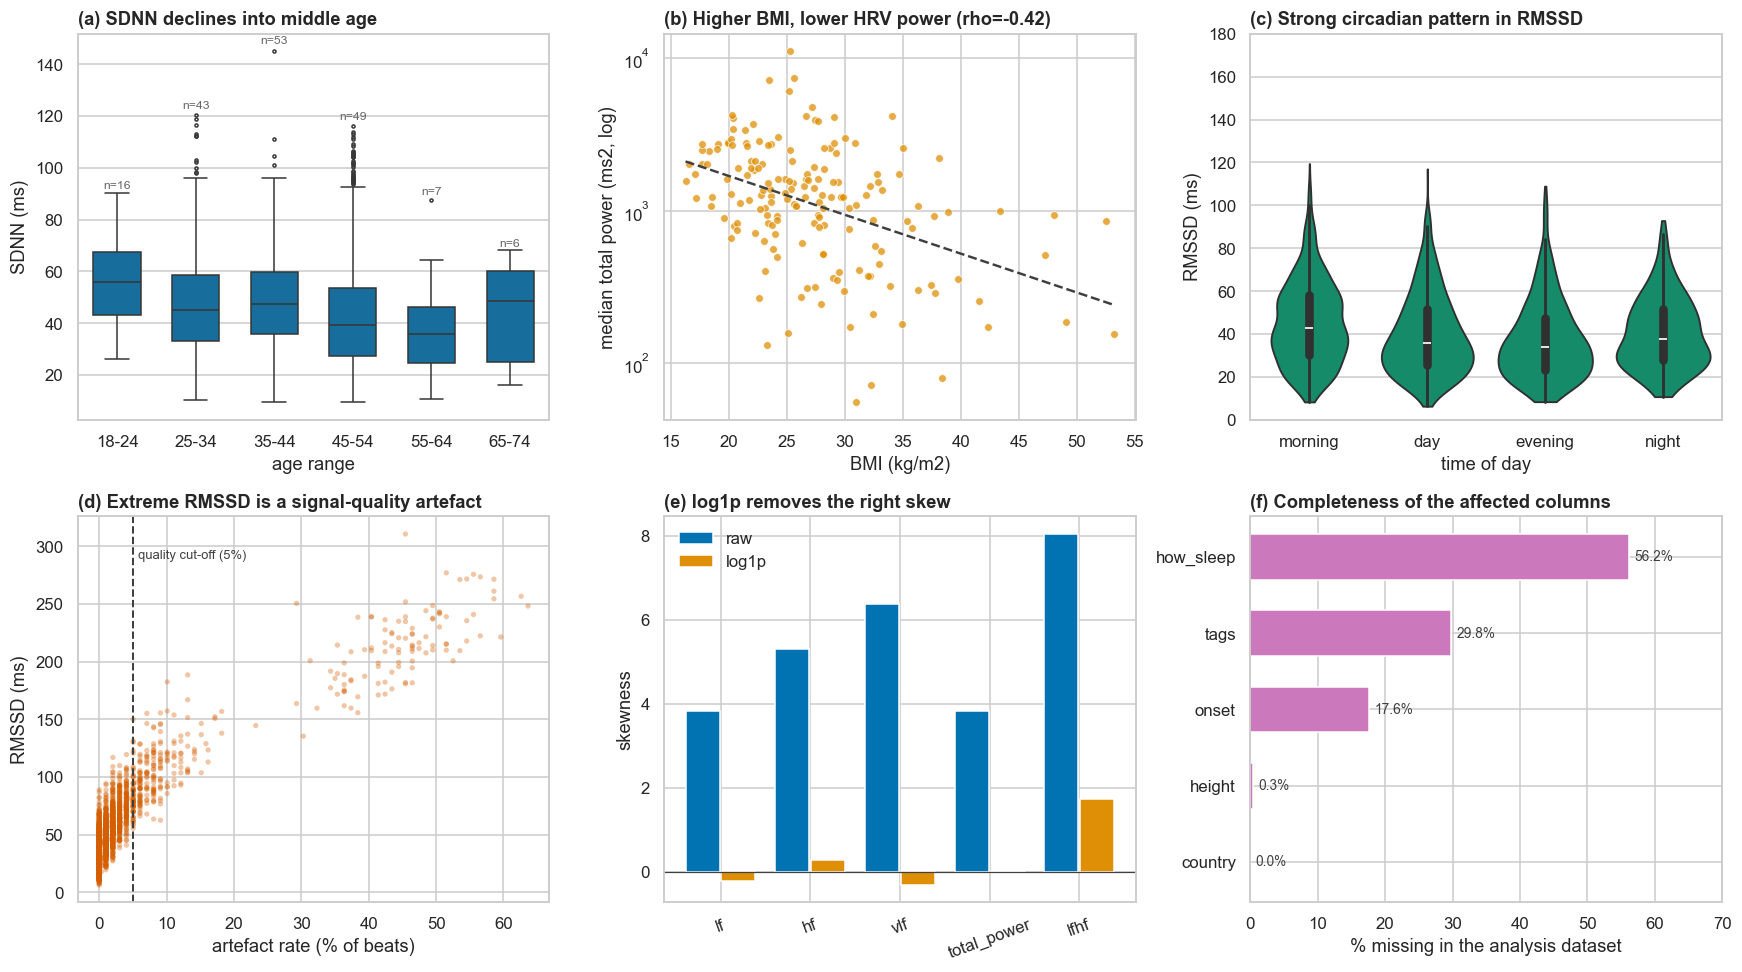

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

ax = axes[0, 0]
sns.boxplot(data=good, x="age_range", y="sdnn", order=AGE_ORDER, color=CAT[0],
            width=.6, fliersize=2, ax=ax)
for i, a in enumerate(AGE_ORDER):
    ax.text(i, good[good.age_range == a].sdnn.max() * 1.02,
            f"n={good[good.age_range == a].user_code.nunique()}", ha="center", fontsize=8, color="#666")
ax.set_title("(a) SDNN declines into middle age"); ax.set_xlabel("age range"); ax.set_ylabel("SDNN (ms)")

ax = axes[0, 1]
ub = u.dropna(subset=["bmi"])
ax.scatter(ub.bmi, ub.total_power, s=26, color=CAT[1], alpha=.75, edgecolor="white", linewidth=.6)
ax.set_yscale("log")
z = np.polyfit(ub.bmi, np.log10(ub.total_power), 1)
xs = np.linspace(ub.bmi.min(), ub.bmi.max(), 50)
ax.plot(xs, 10 ** np.polyval(z, xs), color="#3F3F3F", lw=1.6, ls="--")
ax.set_title(f"(b) Higher BMI, lower HRV power (rho={stats.spearmanr(ub.bmi, ub.total_power).statistic:.2f})")
ax.set_xlabel("BMI (kg/m2)"); ax.set_ylabel("median total power (ms2, log)")

ax = axes[0, 2]
sns.violinplot(data=good, x="time_of_day", y="rmssd", order=["morning", "day", "evening", "night"],
               color=CAT[2], cut=0, ax=ax)
ax.set_ylim(0, 180); ax.set_title("(c) Strong circadian pattern in RMSSD")
ax.set_xlabel("time of day"); ax.set_ylabel("RMSSD (ms)")

ax = axes[1, 0]
ax.scatter(df.artifact_rate, df.rmssd, s=12, alpha=.35, color=CAT[3], edgecolor="none")
ax.axvline(5, color="#3F3F3F", ls="--", lw=1.3)
ax.text(5.8, df.rmssd.max() * .93, "quality cut-off (5%)", fontsize=8.5, color="#3F3F3F")
ax.set_title("(d) Extreme RMSSD is a signal-quality artefact")
ax.set_xlabel("artefact rate (% of beats)"); ax.set_ylabel("RMSSD (ms)")

ax = axes[1, 1]
sk = pd.DataFrame({"raw": df[SKEWED].skew().values,
                   "log1p": df[["log_" + c for c in SKEWED]].skew().values}, index=SKEWED)
x, w = np.arange(len(sk)), .38
ax.bar(x - w / 2 - .01, sk["raw"], w, label="raw", color=CAT[0])
ax.bar(x + w / 2 + .01, sk["log1p"], w, label="log1p", color=CAT[1])
ax.axhline(0, color="#3F3F3F", lw=.8)
ax.set_xticks(x); ax.set_xticklabels(sk.index, rotation=20)
ax.set_title("(e) log1p removes the right skew"); ax.set_ylabel("skewness"); ax.legend(frameon=False)

ax = axes[1, 2]
miss = (100 * df[["how_sleep", "tags", "onset", "height", "country"]].isna().mean()).sort_values()
ax.barh(miss.index, miss.values, color=CAT[4], height=.6)
for y, v in enumerate(miss.values):
    ax.text(v + .8, y, f"{v:.1f}%", va="center", fontsize=9, color="#3F3F3F")
ax.set_xlim(0, 70); ax.set_title("(f) Completeness of the affected columns")
ax.set_xlabel("% missing in the analysis dataset")

plt.tight_layout(); plt.show()

## Interpretation

**(a) The age pattern is U-shaped, and the U is an artefact of sample size.** SDNN falls
from a median of 57 ms in the 18–24 band to 40 ms at 45–54, then appears to rebound at
55–64 and 65–74. The rebound rests on **7 and 6 participants**. It is far more likely to be
survivorship bias — people over 55 who own a wearable and volunteer for HRV research are
unusually healthy — than a genuine reversal of autonomic ageing. The `n=` labels are printed
on the panel precisely so this cannot be read off the boxes without seeing how thin the
tails are. This is the clearest illustration of the sampling limitation from Section 1.

**(b) The BMI relationship is the cleanest in the dataset,** and it needs a log y-axis to
be visible at all — which is itself the argument for the transformation in Section 9. The
spread around the trend is wide, so BMI explains a tendency, not an individual's HRV.

**(c) The circadian violins show more than the medians.** Morning readings are not merely
higher but differently *shaped*: a long upper tail that the evening distribution lacks
entirely. Evening and daytime readings are compressed near the floor. Anyone comparing
groups in this dataset must control for time of day.

**(d) This panel is the argument of Section 8 in one image.** The relationship between
artefact rate and RMSSD is not a cloud with a trend — it is nearly a curve. Every
measurement above ~150 ms RMSSD sits to the right of the 5% cut-off. The points that a Tukey
rule would have clipped as "extreme physiology" are, visibly, bad recordings.

**(e)** Four of the five power metrics land within ±0.3 skew after `log1p`; `lfhf` remains
skewed because it is a ratio of two skewed quantities, and is treated with more caution.

**(f)** Missingness in the analysis dataset is concentrated in the optional self-report
fields (`how_sleep` 56.2%, `tags` 29.8%, `onset` 17.6%), while measured columns are
essentially complete. Percentages differ slightly from Section 5 because retest rows were
removed in Section 7.

# 12. Conclusions and Limitations

## What the exploration established

**The data is trustworthy where it is computed, and unreliable where it is typed.** The
release passes every integrity test available: referential integrity is complete in both
directions, all four duplicate tests return zero, three derived columns satisfy their own
definitions exactly, and — the strongest evidence — all four time-domain HRV metrics
reproduce from the raw `rr_data` waveform at r = 1.0000. But the self-reported columns
contain 2 impossible heights, 13 impossible onset dates, a column with two unit systems
mixed in, and a rating scale whose "complete" values are 61% default. **Provenance predicts
quality better than any column-level statistic does.**

**The documentation cannot be taken at face value.** Three of the release's own published
column definitions disagree with its data: `mode`'s unit, `tags`'s separator, and `pnn50`'s
formula. Each was caught only by testing the documentation against the data instead of
reading it.

**The extremes were measurement noise, not physiology.** 99.0% of the rows a Tukey IQR rule
would have clipped have artefact rates above 5%, versus 6.2% of the rest. The raw waveform
turned an arbitrary statistical threshold into an empirical, physiologically justified one.

**The relationships that survive a correct analysis are the ones the literature predicts.**
BMI (ρ = −0.42) and age (ρ = −0.36) both suppress HRV power; women show higher heart rate
and lower SDNN; and the circadian swing in RMSSD (morning 42.8 vs evening 34.1 ms,
p = 2e-18) is larger than any other effect measured here.

**No acute COVID-19 signature was detected**, and the apparent `illness_phase` effect is
driven by the "no onset reported" group — a selection effect, not a disease effect.

## Limitations

1. **Convenience sample.** Smartphone-owning, app-using, self-selected volunteers, 68% from
   two countries, 64% female, with only 16 participants over 55. No prevalence or clinical
   claim generalises beyond this group.
2. **Severe panel imbalance.** Median 4 measurements per person, max 405; the top 5 supply
   38% of rows. Every between-person statistic here uses per-participant medians for that
   reason, and Section 10F shows what happens when that correction is skipped.
3. **Measurements are ~84 seconds, not the 5 minutes HRV standards require.** SDNN, RMSSD
   and pNN50 are defensible; `lf`, `vlf`, `lfhf` and the absolute level of `stress_index`
   are structurally under-powered and were interpreted only comparatively.
4. **Quality filtering is not neutral.** Excluding noisy recordings removes disproportionately
   high-variability readings, biasing retained HRV slightly downward.
5. **Only two of nine tables were used.** COVID symptom severity lives in `surveys`, so
   disease status entered only as a date. A follow-up joining `surveys` on a ±3-day window
   would add severity at the cost of retaining roughly a quarter of the HRV rows.
6. **Everything here is observational and cross-sectional in effect.** Age and BMI are
   themselves correlated (ρ = +0.28); no causal claim is made or supported.